In [1]:
import glob
import json
import os
import pickle
import socket
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import imageio
import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
for p in [REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

COMP_BASE_DIR = REPO_ROOT / "outputs/can_rollouts/comparison"
MODE2_INITSTATE_ROOT = REPO_ROOT / "outputs/can_rollouts/mode_2_initstates"
GUIDANCE_ROOT = REPO_ROOT / "outputs/can_rollouts/guidance_scheduling"
ENV_NAME = "n16h300r60g1bYfYv1"
WORLD_MODEL_RUN_ROOT = COMP_BASE_DIR / "20260407_210830_v1_s1_50"
WORLD_MODEL_CKPT_ROOT = REPO_ROOT / "models/dynamics/baseline_mlp"
POLICY_CKPT_PATH = Path("/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth")
INIT_STATE_JSON_PATH = REPO_ROOT / "outputs/can_rollouts/snr/n16h300r60g1bYfYv1/init_state.json"
BASE_SEED = 1
INITSTATE_ROLLOUT_SEED = 4
SWEEP_SOURCE_SEED = 4
WORLD_MODEL_SEEDS = [1, 2, 3, 4, 5]
WORLD_MODEL_BRANCH_HORIZON = 8
WORLD_MODEL_BRANCH_STRIDE = 8
TRACE_STEP_IDX = 104
INITSTATE_HORIZON = 300
SWEEP_NUM_ROLLOUTS = 20
SWEEP_HORIZON = 300
ZERO_QVEL_ON_RESET = True
FLAT_RZZ_TOL = 2.5e-4

hostname: gilbreth-n018.rcac.purdue.edu
pid: 167458
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-55651a7d-d167-ecc7-3174-c562bee66c65)


In [2]:
# Load world model, policy, env, and shared helpers once.
from diffusion_comparison import load_model_for_eval, load_policy_and_env, reseed
from world_model_utils import build_state_from_obs_dict, load_init_state_json, predict_next_state_from_raw, rzz_from_state_29d, get_mujoco_rzz_and_pos
import robosuite

def _unwrap_to_attr(root_env, attr_name, max_depth=16):
    probe = root_env
    for _ in range(max_depth):
        if hasattr(probe, attr_name):
            return probe
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    return None


def _sim_handles(root_env):
    sim_holder = _unwrap_to_attr(root_env, "sim")
    if sim_holder is None:
        raise RuntimeError("Could not find MuJoCo sim in env wrappers.")
    sim = sim_holder.sim
    sim_model = getattr(sim, "model", None) or getattr(sim, "_model", None)
    sim_data = getattr(sim, "data", None) or getattr(sim, "_data", None)
    if sim_model is None or sim_data is None:
        raise RuntimeError("Could not access MuJoCo model/data handles from sim.")
    rs_holder = _unwrap_to_attr(root_env, "robots")
    if rs_holder is None:
        raise RuntimeError("Could not find robosuite env with robots list in wrappers.")
    return sim, sim_model, sim_data, rs_holder


def _find_latest_mode2_run(seed):
    pattern = str(MODE2_INITSTATE_ROOT / f"v1_dp_base_seed{seed:02d}_*")
    runs = sorted(glob.glob(pattern))
    if not runs:
        raise FileNotFoundError(f"No mode_2 initstate runs found for seed {seed}: {pattern}")
    return Path(runs[-1])


def _neutralize_controller_startup(rs_env):
    for robot in getattr(rs_env, "robots", []):
        if hasattr(robot, "composite_controller"):
            robot.composite_controller.update_state()

        for ctrl in getattr(robot, "part_controllers", {}).values():
            if hasattr(ctrl, "update"):
                try:
                    ctrl.update(force=True)
                except TypeError:
                    ctrl.update()
            if hasattr(ctrl, "joint_pos") and hasattr(ctrl, "update_initial_joints"):
                ctrl.update_initial_joints(np.array(ctrl.joint_pos))
            if hasattr(ctrl, "set_goal_update_mode"):
                ctrl.set_goal_update_mode("achieved")
            if hasattr(ctrl, "reset_goal"):
                try:
                    ctrl.reset_goal(goal_update_mode="achieved")
                except TypeError:
                    ctrl.reset_goal()

        if hasattr(robot, "composite_controller"):
            robot.composite_controller.reset()


def _clean_reset_to_step104(env_obj, rs_env, sim, sim_model, sim_data, state_dict, zero_qvel=True):
    state_for_reset = dict(state_dict)
    state_vec = np.asarray(state_dict["states"], dtype=np.float64).copy()
    if zero_qvel:
        nq = int(sim_model.nq)
        nv = int(sim_model.nv)
        qvel_start = 1 + nq
        qvel_end = qvel_start + nv
        state_vec[qvel_start:qvel_end] = 0.0
    state_for_reset["states"] = state_vec
    obs = env_obj.reset_to(state_for_reset)
    _neutralize_controller_startup(rs_env)
    if hasattr(sim_data, "ctrl"):
        sim_data.ctrl[:] = 0.0
    mujoco.mj_forward(sim_model._model if hasattr(sim_model, "_model") else sim_model, sim_data._data if hasattr(sim_data, "_data") else sim_data)


    zero_act = np.zeros(7)
    zero_act[6] = 1
    for _ in range(8):
        obs, _, _, _ = env.step(zero_act)
    return obs, state_for_reset


device = "cuda" if torch.cuda.is_available() else "cpu"
predictor, predictor_stats, _, predictor_meta = load_model_for_eval(
    model_or_run_path=str(WORLD_MODEL_CKPT_ROOT),
    device=device,
    predictor_kind="learned",
    load_val_trajectories=False,
)
env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=True)
sim, sim_model, sim_data, rs_holder = _sim_handles(env)
init_state_json = load_init_state_json(str(INIT_STATE_JSON_PATH))

print(f"world model: {predictor_meta['ckpt_path']}")
print(f"policy ckpt: {POLICY_CKPT_PATH}")
print(f"device: {device}")
print(f"env ready: {type(env).__name__}")
print(f"sim model nq/nv: {sim_model.nq}/{sim_model.nv}")

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/zoellner/src/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
/home/zoellner/.conda/envs/guided_diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'object', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
   

### World Model Performance Testing Mid-Mode

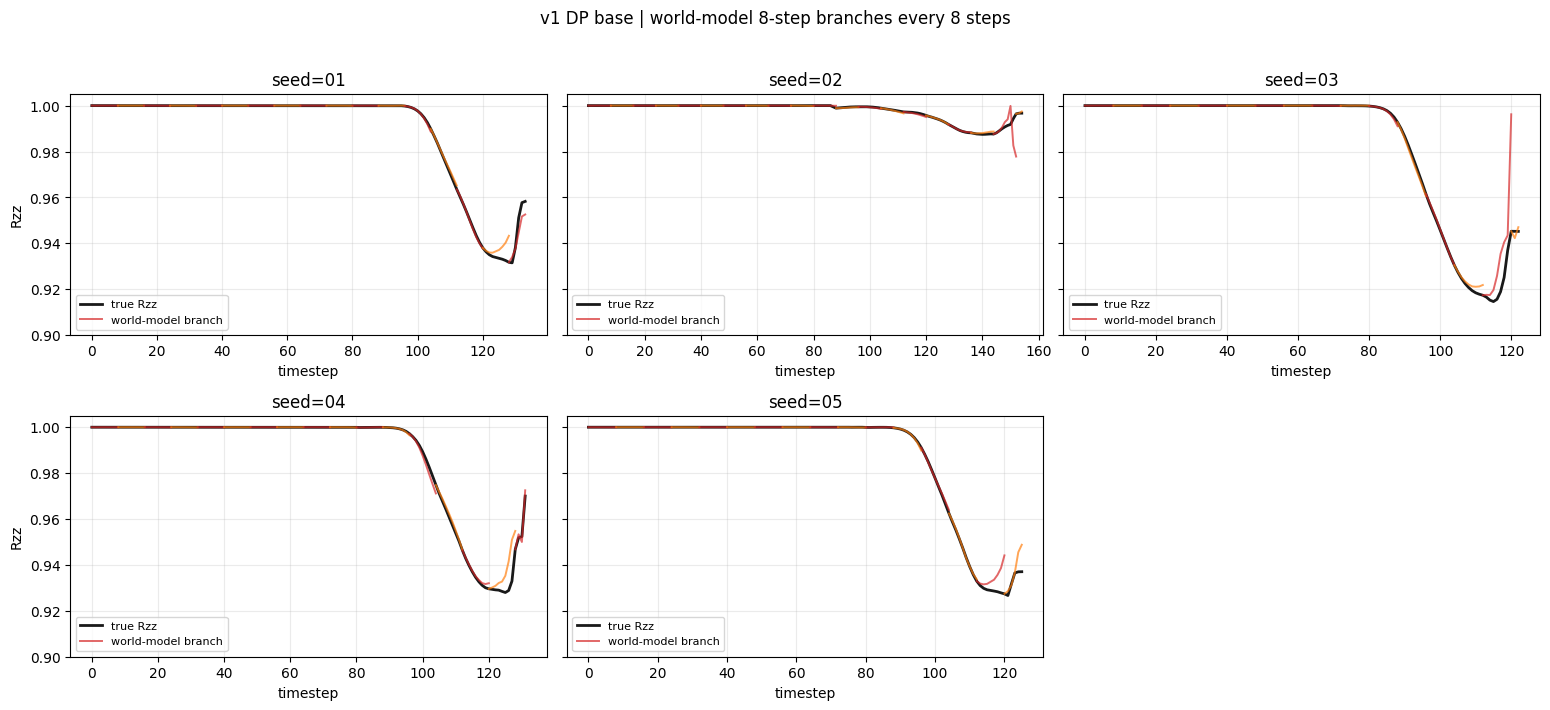

In [3]:
# World-model branches for seeds 1..5.
run_root = WORLD_MODEL_RUN_ROOT
method_slug = "dp_base"
branch_colors = ["#d62728", "#ff7f0e"]

n_methods = len(WORLD_MODEL_SEEDS)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), sharey=True)
axes = np.atleast_1d(axes).reshape(-1)

for ax, seed in zip(axes[:n_methods], WORLD_MODEL_SEEDS):
    npz_path = run_root / method_slug / f"{ENV_NAME}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing rollout file: {npz_path}")

    data = np.load(npz_path)
    states = np.asarray(data["states"], dtype=np.float32)
    actions = np.asarray(data["actions"], dtype=np.float32)
    true_rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    ax.plot(np.arange(len(true_rzz)), true_rzz, lw=2.0, color="black", alpha=0.9, label="true Rzz")

    first_branch_label = True
    for branch_idx, t0 in enumerate(range(0, len(actions), WORLD_MODEL_BRANCH_STRIDE)):
        s_roll = np.asarray(states[t0], dtype=np.float32).copy()
        branch_rzz = [true_rzz[t0]]
        k_max = min(WORLD_MODEL_BRANCH_HORIZON, len(actions) - t0)
        for k in range(k_max):
            s_roll = predict_next_state_from_raw(s_roll, actions[t0 + k], predictor, predictor_stats, device)
            branch_rzz.append(rzz_from_state_29d(s_roll))
        x_branch = np.arange(t0, t0 + len(branch_rzz))
        color = branch_colors[branch_idx % len(branch_colors)]
        ax.plot(x_branch, np.asarray(branch_rzz, dtype=np.float32), color=color, lw=1.4, alpha=0.7, label="world-model branch" if first_branch_label else None)
        first_branch_label = False

    ax.set_title(f"seed={seed:02d}")
    ax.set_xlabel("timestep")
    ax.set_ylim(0.90, 1.005)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, frameon=True, loc="best")

for idx, ax in enumerate(axes[:n_methods]):
    if idx % ncols == 0:
        ax.set_ylabel("Rzz")
for ax in axes[n_methods:]:
    ax.axis("off")
plt.suptitle("v1 DP base | world-model 8-step branches every 8 steps", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Seed-4 init-state rollout: save per-step init states and obs/action trace.
14
run_dir = MODE2_INITSTATE_ROOT / f"v1_dp_base_seed{INITSTATE_ROLLOUT_SEED:02d}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

reseed(INITSTATE_ROLLOUT_SEED)
policy.start_episode()
env.reset()
obs = env.reset_to(init_state_json)

saved_paths = []
rollout_trace = []
total_reward = 0.0
success = False
steps_executed = 0
for step_idx in range(INITSTATE_HORIZON):
    state_snapshot = env.get_state()
    step_path = run_dir / f"init_state_step_{step_idx:04d}.pkl"
    with step_path.open("wb") as f:
        pickle.dump(state_snapshot, f, protocol=pickle.HIGHEST_PROTOCOL)
    saved_paths.append(str(step_path))

    obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
    act = np.asarray(policy(ob=obs_snapshot), dtype=np.float32)
    act = np.nan_to_num(act, nan=0.0, posinf=0.0, neginf=0.0)
    act = np.clip(act, -1.0, 1.0)

    next_obs, reward, done, _ = env.step(act)
    total_reward += float(reward)
    steps_executed = step_idx + 1
    status = env.is_success()
    success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
    rollout_trace.append({"step_idx": int(step_idx), "state_path": str(step_path), "obs": obs_snapshot, "action": act.copy(), "reward": float(reward), "done": bool(done), "success": bool(success)})
    obs = next_obs
    if done or success:
        break

final_path = run_dir / f"init_state_step_{steps_executed:04d}_final.pkl"
with final_path.open("wb") as f:
    pickle.dump(env.get_state(), f, protocol=pickle.HIGHEST_PROTOCOL)
saved_paths.append(str(final_path))
trace_path = run_dir / "rollout_trace.pkl"
with trace_path.open("wb") as f:
    pickle.dump(rollout_trace, f, protocol=pickle.HIGHEST_PROTOCOL)
manifest = {"seed": INITSTATE_ROLLOUT_SEED, "horizon_requested": INITSTATE_HORIZON, "steps_executed": steps_executed, "success": bool(success), "total_reward": float(total_reward), "init_state_path": str(INIT_STATE_JSON_PATH), "policy_ckpt_path": str(POLICY_CKPT_PATH), "saved_initstate_count": len(saved_paths), "saved_initstate_files": saved_paths, "trace_path": str(trace_path), "run_dir": str(run_dir)}
(run_dir / "rollout_manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"run dir: {run_dir}")
print(f"success: {success} | steps_executed: {steps_executed} | total_reward: {total_reward:.4f}")
print(f"saved init-state snapshots: {len(saved_paths)}")
print(f"saved rollout trace: {trace_path}")

In [ ]:
# 20-rollout sweep from exact step 104, using controller-neutralized reset.
source_mode2_run = _find_latest_mode2_run(SWEEP_SOURCE_SEED)
step_state_path = source_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)
trace_path = source_mode2_run / "rollout_trace.pkl"
with trace_path.open("rb") as f:
    rollout_trace = pickle.load(f)
trace_entry = next((row for row in rollout_trace if row.get("step_idx") == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path}")
trace_obs_step = trace_entry["obs"]

batch_dir = GUIDANCE_ROOT / "diversity" / f"seed05_from_step0104_batch_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
batch_dir.mkdir(parents=True, exist_ok=True)

all_rzz = []
summary_rows = []
for run_idx in range(SWEEP_NUM_ROLLOUTS):
    rollout_seed = int(BASE_SEED + run_idx)
    run_dir_i = batch_dir / f"rollout_{run_idx + 1:02d}"
    run_dir_i.mkdir(parents=True, exist_ok=True)
    video_path_i = run_dir_i / "rollout.mp4"
    snapshot_path_i = run_dir_i / "step0104_snapshot_frontview.png"
    trace_out_path_i = run_dir_i / "obs_act_trace.pkl"
    stats_path_i = run_dir_i / "rollout_stats.json"

    reseed(rollout_seed)
    policy.start_episode()
    env.reset()
    obs, _ = _clean_reset_to_step104(env, rs_holder, sim, sim_model, sim_data, init_state_step104, zero_qvel=ZERO_QVEL_ON_RESET)
    obs = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))

    frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
    imageio.imwrite(snapshot_path_i, frame0)

    writer = imageio.get_writer(str(video_path_i), fps=20)
    rzz_series = []
    obs_act_trace = []
    total_reward = 0.0
    success = False
    steps_executed = 0
    try:
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))
        writer.append_data(frame0)
        for step_idx in range(SWEEP_HORIZON):
            obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
            act = np.asarray(policy(ob=obs_snapshot), dtype=np.float32)
            act = np.nan_to_num(act, nan=0.0, posinf=0.0, neginf=0.0)
            act = np.clip(act, -1.0, 1.0)
            next_obs, reward, done, _ = env.step(act)
            frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
            writer.append_data(frame_t)
            rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            rzz_series.append(float(rzz_t))
            status = env.is_success()
            success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
            obs_act_trace.append({"step_idx": int(step_idx), "obs": obs_snapshot, "action": act.copy(), "reward": float(reward), "done": bool(done), "success": bool(success), "can_rzz": float(rzz_t)})
            total_reward += float(reward)
            steps_executed = step_idx + 1
            obs = next_obs
            if done or success:
                break
    finally:
        writer.close()

    with trace_out_path_i.open("wb") as f:
        pickle.dump(obs_act_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

    rollout_stats = {"rollout_index": int(run_idx + 1), "rollout_seed": int(rollout_seed), "source_mode2_run": str(source_mode2_run), "source_step_state_path": str(step_state_path), "source_trace_path": str(trace_path), "source_trace_step_idx": int(TRACE_STEP_IDX), "steps_executed": int(steps_executed), "success": bool(success), "total_reward": float(total_reward), "initial_rzz": float(rzz_series[0]) if rzz_series else float("nan"), "final_rzz": float(rzz_series[-1]) if rzz_series else float("nan"), "video_path": str(video_path_i), "snapshot_path": str(snapshot_path_i), "obs_act_trace_path": str(trace_out_path_i), "run_dir": str(run_dir_i)}
    stats_path_i.write_text(json.dumps(rollout_stats, indent=2))
    all_rzz.append(np.asarray(rzz_series, dtype=np.float32))
    summary_rows.append(rollout_stats)

batch_manifest = {"num_rollouts": int(SWEEP_NUM_ROLLOUTS), "policy_ckpt_path": str(POLICY_CKPT_PATH), "base_seed": int(BASE_SEED), "horizon_requested": int(SWEEP_HORIZON), "source_mode2_run": str(source_mode2_run), "source_step_state_path": str(step_state_path), "source_trace_path": str(trace_path), "source_trace_step_idx": int(TRACE_STEP_IDX), "batch_dir": str(batch_dir), "rollouts": summary_rows}
(batch_dir / "batch_manifest.json").write_text(json.dumps(batch_manifest, indent=2))


In [ ]:
run_root = WORLD_MODEL_RUN_ROOT
method_slug = "dp_base"
true_rollout_rzz = []
for row in rollout_trace:
    if int(row.get("step_idx", -1)) >= TRACE_STEP_IDX:
        true_state_29d = build_state_from_obs_dict(row["obs"])
        true_rollout_rzz.append(rzz_from_state_29d(true_state_29d))
seed_overlay_specs = [(4, "-", 2.8), (5, "--", 2.8)]
seed_overlay_rzz = []
for seed, linestyle, linewidth in seed_overlay_specs:
    npz_path = run_root / method_slug / f"{ENV_NAME}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing rollout file: {npz_path}")
    data = np.load(npz_path)
    states = np.asarray(data["states"], dtype=np.float32)
    rzz_traj = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    seed_overlay_rzz.append((seed, rzz_traj, linestyle, linewidth))

plt.figure(figsize=(10, 5.5))
for i, rzz in enumerate(all_rzz):
    plt.plot(np.arange(len(rzz)), rzz, lw=1.2, alpha=0.75, label="rollouts" if i == 0 else None)
if true_rollout_rzz:
    plt.plot(np.arange(len(true_rollout_rzz)), true_rollout_rzz, color="black", linewidth=2.8, label="true rollout from step 104")
for seed, rzz_traj, linestyle, linewidth in seed_overlay_rzz:
    rzz_traj = rzz_traj[104:]
    plt.plot(np.arange(len(rzz_traj)), rzz_traj, color="black", linestyle=linestyle, linewidth=linewidth, alpha=0.8, label=f"seed {seed:02d} true rollout")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.7, label="0.97 threshold")
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Diversity sweep: 20 rollouts from step-104")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
print(f"batch dir: {batch_dir}")
print(f"num rollouts: {SWEEP_NUM_ROLLOUTS} | successes: {sum(1 for r in summary_rows if r['success'])}/{SWEEP_NUM_ROLLOUTS}")
print(f"batch manifest: {batch_dir / 'batch_manifest.json'}")

In [ ]:
# Hardcoded action from the cleansed step-104 state (c=0.05).
source_mode2_run = _find_latest_mode2_run(SWEEP_SOURCE_SEED)
step_state_path = source_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)
trace_path_source = source_mode2_run / "rollout_trace.pkl"
with trace_path_source.open("rb") as f:
    rollout_trace_source = pickle.load(f)
trace_entry = next((row for row in rollout_trace_source if int(row.get("step_idx", -1)) == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path_source}")
trace_obs_step = pickle.loads(pickle.dumps(trace_entry["obs"], protocol=pickle.HIGHEST_PROTOCOL))

HARD_CODED_C = -0.04
HARD_CODED_SIGN = 1.0
HARD_CODED_STEPS = 63

reseed(BASE_SEED)
policy.start_episode()
env.reset()
obs, state_for_reset = _clean_reset_to_step104(env, rs_holder, sim, sim_model, sim_data, init_state_step104, zero_qvel=ZERO_QVEL_ON_RESET)
# Use the recorded true rollout obs at step 104 as obs_0 instead of reset_to output.
# obs = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))


template_act = np.asarray(policy(ob=obs), dtype=np.float32)
hardcoded_act = np.zeros_like(template_act)
if hardcoded_act.shape[0] >= 5:
    hardcoded_act[3] = float(HARD_CODED_SIGN * HARD_CODED_C)
    hardcoded_act[4] = float(HARD_CODED_SIGN * HARD_CODED_C / 2.0)
if hardcoded_act.shape[0] >= 7:
    hardcoded_act[6] = 1.0

action_entries_slug = "__".join(f"{v:.6g}" for v in hardcoded_act.tolist())
run_dir = GUIDANCE_ROOT / "hardcoded" / f"act_{action_entries_slug}_steps{HARD_CODED_STEPS}_seed{SWEEP_SOURCE_SEED:02d}_t{TRACE_STEP_IDX:04d}"
run_dir.mkdir(parents=True, exist_ok=True)
video_path = run_dir / "hardcoded_rollout.mp4"
plot_path = run_dir / "hardcoded_rzz_plot.png"
stats_path = run_dir / "hardcoded_rollout_stats.json"
trace_path = run_dir / "hardcoded_obs_act_trace.pkl"

writer = imageio.get_writer(str(video_path), fps=20)
rzz_series = []
rewards = []
obs_act_trace = []
success = False
steps_executed = 0
try:
    frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
    writer.append_data(frame0)
    rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
    rzz_series.append(float(rzz0))
    for step_idx in range(HARD_CODED_STEPS):
        obs_snapshot = pickle.loads(pickle.dumps(obs, protocol=pickle.HIGHEST_PROTOCOL))
        next_obs, reward, done, _ = env.step(hardcoded_act)
        frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame_t)
        rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz_t))
        rewards.append(float(reward))
        status = env.is_success()
        success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
        steps_executed = step_idx + 1
        obs_act_trace.append({"step_idx": int(step_idx), "obs": obs_snapshot, "action": hardcoded_act.copy(), "reward": float(reward), "done": bool(done), "success": bool(success), "can_rzz": float(rzz_t)})
        obs = next_obs
        if done or success:
            break
finally:
    writer.close()

with trace_path.open("wb") as f:
    pickle.dump(obs_act_trace, f, protocol=pickle.HIGHEST_PROTOCOL)

rzz_arr = np.asarray(rzz_series, dtype=np.float32)
drift = float(np.ptp(rzz_arr)) if len(rzz_arr) else float("nan")
slope = float(np.polyfit(np.arange(len(rzz_arr), dtype=np.float32), rzz_arr, 1)[0]) if len(rzz_arr) >= 2 else 0.0
is_flat = bool(drift <= FLAT_RZZ_TOL) if np.isfinite(drift) else False
state_reload_err = float(np.max(np.abs(np.asarray(env.get_state()["states"], dtype=np.float64) - np.asarray(state_for_reset["states"], dtype=np.float64))))

plt.figure(figsize=(8.8, 4.8))
plt.plot(np.arange(len(rzz_arr)), rzz_arr, lw=2.0, color="#1f77b4")
plt.axhline(1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.8, label="1.00 reference")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.ylim(0.92, 1.002)
plt.xlabel("timestep")
plt.ylabel("can Rzz (mujoco)")
plt.title("Hardcoded rotational action from cleansed step-104")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

stats = {"source_mode2_run": str(source_mode2_run), "source_step_state_path": str(step_state_path), "source_trace_path": str(trace_path_source), "source_trace_step_idx": int(TRACE_STEP_IDX), "seed": int(BASE_SEED), "zero_qvel_on_reset": bool(ZERO_QVEL_ON_RESET), "hardcoded_c": float(HARD_CODED_C), "hardcoded_sign": float(HARD_CODED_SIGN), "state_reload_max_abs_err": float(state_reload_err), "steps_executed": int(steps_executed), "success": bool(success), "total_reward": float(np.sum(rewards) if rewards else 0.0), "initial_rzz": float(rzz_arr[0]) if len(rzz_arr) else float("nan"), "final_rzz": float(rzz_arr[-1]) if len(rzz_arr) else float("nan"), "rzz_drift_ptp": float(drift), "rzz_slope_per_step": float(slope), "is_flat": bool(is_flat), "video_path": str(video_path), "plot_path": str(plot_path), "trace_path": str(trace_path), "run_dir": str(run_dir)}
stats_path.write_text(json.dumps(stats, indent=2))
print(f"run dir: {run_dir}")
print(f"hardcoded action: {hardcoded_act.tolist()}")
print(f"state reload max abs err: {state_reload_err:.3e}")
print(f"drift={drift:.6f}, slope={slope:+.6e}, flat={is_flat}")
print(f"plot: {plot_path}")
print(f"video: {video_path}")
print(f"stats: {stats_path}")

In [ ]:
# World-model sanity check on all hardcoded rollouts: black true traj + 8-step WM branches.
hardcoded_root = GUIDANCE_ROOT / "hardcoded"
run_dirs = sorted([p for p in hardcoded_root.iterdir() if p.is_dir()])

rollout_payloads = []
for run_dir in run_dirs:
    trace_path = run_dir / "hardcoded_obs_act_trace.pkl"
    if not trace_path.exists():
        continue

    with trace_path.open("rb") as f:
        trace = pickle.load(f)
    if not trace:
        continue

    states = []
    actions = []
    for row in trace:
        if "obs" not in row or "action" not in row:
            continue
        states.append(build_state_from_obs_dict(row["obs"]))
        actions.append(np.asarray(row["action"], dtype=np.float32))

    if len(states) == 0 or len(actions) == 0:
        continue

    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    true_rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)

    # Start first WM branch at step 1 when available.
    start_idx = 0 if len(states) > 1 and len(actions) > 1 else 0
    s_roll = states[start_idx].copy()
    wm_first_branch = [float(true_rzz[start_idx])]
    k_max = min(WORLD_MODEL_BRANCH_HORIZON, len(actions) - start_idx)
    for k in range(k_max):
        s_roll = predict_next_state_from_raw(s_roll, actions[start_idx + k], predictor, predictor_stats, device)
        wm_first_branch.append(rzz_from_state_29d(s_roll))

    wm_delta8 = float(wm_first_branch[-1] - wm_first_branch[0]) if len(wm_first_branch) >= 2 else float("nan")
    true_end_idx = min(start_idx + k_max, len(true_rzz) - 1)
    true_delta8 = float(true_rzz[true_end_idx] - true_rzz[start_idx]) if len(true_rzz) >= 2 else float("nan")

    rollout_payloads.append(
        {
            "name": run_dir.name,
            "states": states,
            "actions": actions,
            "true_rzz": true_rzz,
            "wm_delta8": wm_delta8,
            "true_delta8": true_delta8,
            "start_idx": start_idx,
        }
    )

if not rollout_payloads:
    raise FileNotFoundError(f"No hardcoded rollout traces found under: {hardcoded_root}")

n = len(rollout_payloads)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.4 * nrows), sharey=False)
axes = np.atleast_1d(axes).reshape(-1)
branch_colors = ["#d62728", "#ff7f0e"]

for i, payload in enumerate(rollout_payloads):
    ax = axes[i]
    states = payload["states"]
    actions = payload["actions"]
    true_rzz = payload["true_rzz"]
    start_idx = payload["start_idx"]

    print(true_rzz)
    ax.plot(np.arange(len(true_rzz)), true_rzz, lw=2.0, color="black", alpha=0.95, label="true Rzz")

    first_branch_label = True
    for branch_idx, t0 in enumerate(range(start_idx, len(actions), WORLD_MODEL_BRANCH_STRIDE)):
        s_roll = np.asarray(states[t0], dtype=np.float32).copy()
        branch_rzz = [float(true_rzz[t0])]
        k_max = min(WORLD_MODEL_BRANCH_HORIZON, len(actions) - t0)
        for k in range(k_max):
            s_roll = predict_next_state_from_raw(s_roll, actions[t0 + k], predictor, predictor_stats, device)
            branch_rzz.append(rzz_from_state_29d(s_roll))

        x_branch = np.arange(t0, t0 + len(branch_rzz))
        color = branch_colors[branch_idx % len(branch_colors)]
        ax.plot(
            x_branch,
            np.asarray(branch_rzz, dtype=np.float32),
            color=color,
            lw=1.4,
            alpha=0.8,
            label="WM 8-step branch" if first_branch_label else None,
        )
        first_branch_label = False

    ax.relim()
    ax.autoscale_view()
    default_ymin, _ = ax.get_ylim()

    ax.axhline(1.0, color="black", linestyle=":", linewidth=0.9, alpha=0.8)
    ax.axhline(0.97, color="black", linestyle="--", linewidth=0.9, alpha=0.75)
    ax.set_ylim(min(default_ymin, 0.968), 1.002)
    ax.grid(alpha=0.25)
    ax.set_xlabel("timestep")
    ax.set_title(f"{payload['name']}\nWM d8={payload['wm_delta8']:+.4f} | true d8={payload['true_delta8']:+.4f}", fontsize=9)
    if i % ncols == 0:
        ax.set_ylabel("Rzz")
    ax.legend(fontsize=7, frameon=True, loc="best")

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Hardcoded rollouts: true trajectory vs world-model 8-step branches", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
print(f"hardcoded runs analyzed: {n}")

### Policy Guidance after Denoising

ObservationKeyToModalityDict: robot0_joint_pos not found, adding robot0_joint_pos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_cos not found, adding robot0_joint_pos_cos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_sin not found, adding robot0_joint_pos_sin to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_vel not found, adding robot0_joint_vel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_eef_quat_site not found, adding robot0_eef_quat_site to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_gripper_qvel not found, adding robot0_gripper_qvel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: lang_emb not found, adding lang_emb to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
Observat

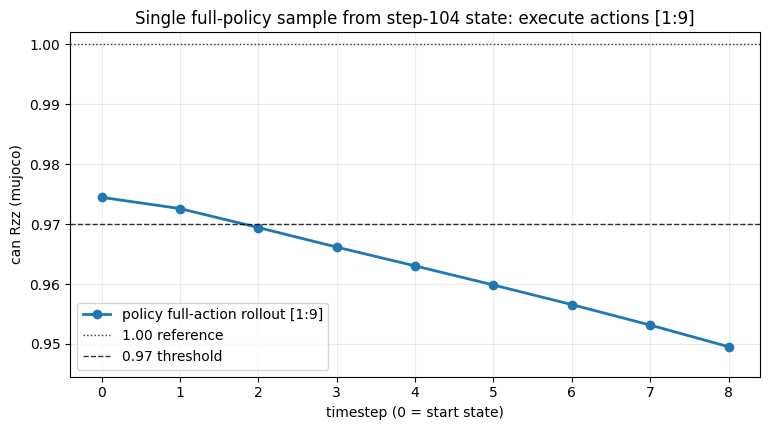

source run: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/mode_2_initstates/v1_dp_base_seed04_20260409_175307
full_action shape: (16, 7)
executed action_series shape: (8, 7)
steps executed: 8
executed actions [1:9]:
[[ 0.22655745  0.99871236  0.25853404  0.06139041  0.09470861 -0.18087098
   0.99893594]
 [ 0.09837124  0.98855776  0.34033498  0.06153288  0.0868072  -0.18515812
   0.99999183]
 [ 0.07102872  0.98267853  0.26873782  0.06415255  0.08201078 -0.19345707
   1.        ]
 [ 0.11465136  0.98782986  0.20737433  0.06588469  0.06710852 -0.20608793
   1.        ]
 [ 0.06978437  0.9811206   0.35633448  0.07034825  0.06162314 -0.21559915
   1.        ]
 [ 0.25446203  0.98971534  0.48334655  0.076703    0.05577043 -0.22572336
   0.99687886]
 [ 0.2384787   0.9918396   0.58577484  0.07851061  0.05387842 -0.23595728
   1.        ]
 [ 0.3125133   0.98573077  0.5158953   0.08050933  0.05463717 -0.23640282
   0.99909043]]


In [3]:
# One policy horizon sample from validated step-104 init/obs, then execute actions [1:9].
source_mode2_run = _find_latest_mode2_run(SWEEP_SOURCE_SEED)
step_state_path = source_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

trace_path_source = source_mode2_run / "rollout_trace.pkl"
with trace_path_source.open("rb") as f:
    rollout_trace_source = pickle.load(f)
trace_entry = next((row for row in rollout_trace_source if int(row.get("step_idx", -1)) == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path_source}")
trace_obs_step = pickle.loads(pickle.dumps(trace_entry["obs"], protocol=pickle.HIGHEST_PROTOCOL))

reseed(BASE_SEED)
policy.start_episode()
env.reset()
obs, _ = _clean_reset_to_step104(
    env, rs_holder, sim, sim_model, sim_data, init_state_step104, zero_qvel=ZERO_QVEL_ON_RESET
)
# Use the validated observation at step 104.
obs = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))

obs_torch = policy._prepare_observation(obs)
with torch.no_grad():
    full_action = policy.policy.get_full_action(obs_torch)
full_action_np = np.asarray(full_action.detach().cpu().numpy()[0], dtype=np.float32)
action_series = np.asarray(full_action_np[1:9], dtype=np.float32)

rzz_series = []
rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
rzz_series.append(float(rzz0))

for act in action_series:
    act = np.nan_to_num(act, nan=0.0, posinf=0.0, neginf=0.0)
    act = np.clip(act, -1.0, 1.0)
    _, _, done, _ = env.step(act)
    rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
    rzz_series.append(float(rzz_t))
    if done:
        break

rzz_arr = np.asarray(rzz_series, dtype=np.float32)

plt.figure(figsize=(7.8, 4.4))
plt.plot(np.arange(len(rzz_arr)), rzz_arr, marker="o", lw=2.0, color="#1f77b4", label="policy full-action rollout [1:9]")
plt.axhline(1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.8, label="1.00 reference")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
plt.ylim(min(float(np.min(rzz_arr)) - 0.005, 0.965), 1.002)
plt.xlabel("timestep (0 = start state)")
plt.ylabel("can Rzz (mujoco)")
plt.title("Single full-policy sample from step-104 state: execute actions [1:9]")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"source run: {source_mode2_run}")
print(f"full_action shape: {full_action_np.shape}")
print(f"executed action_series shape: {action_series.shape}")
print(f"steps executed: {len(rzz_arr) - 1}")
print("executed actions [1:9]:")
print(action_series)

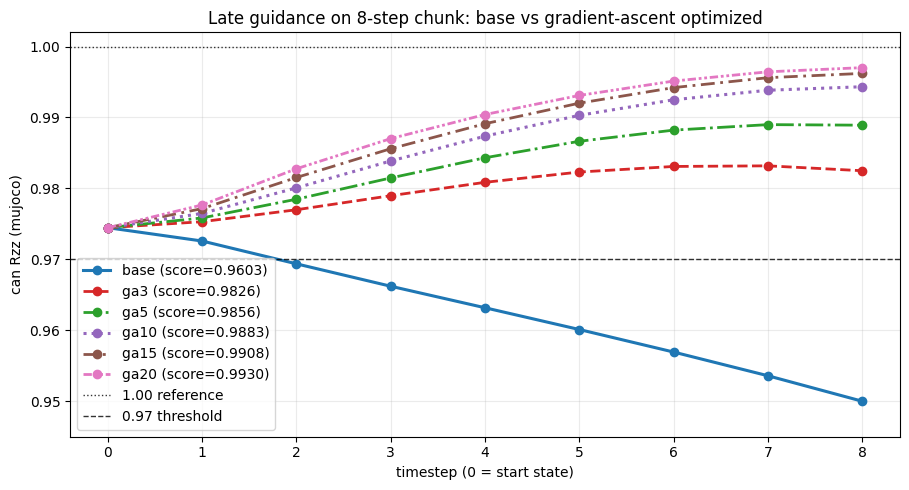

late-guidance run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426
base video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426/base_rollout.mp4
ga3 video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426/ga3_rollout.mp4
ga5 video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426/ga5_rollout.mp4
ga10 video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426/ga10_rollout.mp4
ga15 video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/late_guidance/seed04_t0104_lr2.5_20260410_022426/ga15_rollout.mp4
ga20 video: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_sc

In [4]:
# Late guidance on 8-step chunk: base vs gradient-ascent optimized (3, 5, 10 steps).
from diffusion_comparison import _make_world_model_scoring_helpers

source_mode2_run = _find_latest_mode2_run(SWEEP_SOURCE_SEED)
step_state_path = source_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

trace_path_source = source_mode2_run / "rollout_trace.pkl"
with trace_path_source.open("rb") as f:
    rollout_trace_source = pickle.load(f)
trace_entry = next((row for row in rollout_trace_source if int(row.get("step_idx", -1)) == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path_source}")
trace_obs_step = pickle.loads(pickle.dumps(trace_entry["obs"], protocol=pickle.HIGHEST_PROTOCOL))

score_fn, _ = _make_world_model_scoring_helpers(
    predictor=predictor,
    stats=predictor_stats,
    device=device,
    rollout_steps=8,
    objective="can_rzz",
)

GA_LR = 2.5
GA_STEPS_LIST = [3, 5, 10, 15, 20]
EXEC_SLICE = slice(1, 9)

def reset_to_validated_start():
    policy.start_episode()
    env.reset()
    obs_local, _ = _clean_reset_to_step104(
        env, rs_holder, sim, sim_model, sim_data, init_state_step104, zero_qvel=ZERO_QVEL_ON_RESET
    )
    obs_local = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))
    return obs_local

def rollout_with_fixed_actions(action_seq, video_path):
    obs_local = reset_to_validated_start()
    writer = imageio.get_writer(str(video_path), fps=20)
    rzz_series = []
    try:
        frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame0)
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))

        for act in action_seq:
            act = np.nan_to_num(np.asarray(act, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
            act = np.clip(act, -1.0, 1.0)
            obs_local, _, done, _ = env.step(act)
            frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
            writer.append_data(frame_t)
            rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
            rzz_series.append(float(rzz_t))
            if done:
                break
    finally:
        writer.close()
    return np.asarray(rzz_series, dtype=np.float32)

def optimize_actions(base_actions_np, state_now_np, n_steps, lr):
    a = torch.tensor(base_actions_np, device=device, dtype=torch.float32).unsqueeze(0)
    for _ in range(int(n_steps)):
        a = a.detach().requires_grad_(True)
        objective = score_fn(state_now_np, a).mean()
        grad = torch.autograd.grad(objective, a, retain_graph=False, create_graph=False)[0]
        with torch.no_grad():
            a = torch.clamp(a + float(lr) * grad, -1.0, 1.0)
    return a.detach().squeeze(0).cpu().numpy()

# Base 8-step chunk from one full policy sample at validated start state.
obs_start = reset_to_validated_start()
state_now = build_state_from_obs_dict(obs_start)
obs_torch = policy._prepare_observation(obs_start)
with torch.no_grad():
    full_action = policy.policy.get_full_action(obs_torch)
full_action_np = np.asarray(full_action.detach().cpu().numpy()[0], dtype=np.float32)
base_actions = np.asarray(full_action_np[EXEC_SLICE], dtype=np.float32)

variants = {"base": base_actions}
for n_steps in GA_STEPS_LIST:
    variants[f"ga{n_steps}"] = optimize_actions(base_actions, state_now, n_steps=n_steps, lr=GA_LR)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = GUIDANCE_ROOT / "late_guidance" / f"seed{SWEEP_SOURCE_SEED:02d}_t{TRACE_STEP_IDX:04d}_lr{GA_LR:g}_{ts}"
run_dir.mkdir(parents=True, exist_ok=True)

rzz_by_variant = {}
score_by_variant = {}
for name, action_seq in variants.items():
    video_path = run_dir / f"{name}_rollout.mp4"
    rzz_by_variant[name] = rollout_with_fixed_actions(action_seq, video_path)
    with torch.no_grad():
        score_val = score_fn(state_now, torch.tensor(action_seq, device=device, dtype=torch.float32).unsqueeze(0)).item()
    score_by_variant[name] = float(score_val)

plt.figure(figsize=(9.2, 5.0))
style = {
    "base": ("#1f77b4", "-", 2.2),
    "ga3": ("#d62728", "--", 2.0),
    "ga5": ("#2ca02c", "-.", 2.0),
    "ga10": ("#9467bd", ":", 2.2),
    "ga15": ("#8c564b", (0, (5, 2, 1, 2)), 2.0),
    "ga20": ("#e377c2", (0, (3, 1, 1, 1, 1, 1)), 2.0),
}
for name in ["base", "ga3", "ga5", "ga10", "ga15", "ga20"]:
    if name not in rzz_by_variant:
        continue
    color, ls, lw = style[name]
    arr = rzz_by_variant[name]
    plt.plot(np.arange(len(arr)), arr, color=color, linestyle=ls, linewidth=lw, marker="o", label=f"{name} (score={score_by_variant[name]:.4f})")

plt.axhline(1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.8, label="1.00 reference")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")
all_vals = np.concatenate([v for v in rzz_by_variant.values() if len(v) > 0])
plt.ylim(min(float(np.min(all_vals)) - 0.005, 0.965), 1.002)
plt.xlabel("timestep (0 = start state)")
plt.ylabel("can Rzz (mujoco)")
plt.title("Late guidance on 8-step chunk: base vs gradient-ascent optimized")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

save_payload = {
    "run_dir": str(run_dir),
    "source_mode2_run": str(source_mode2_run),
    "source_step_state_path": str(step_state_path),
    "source_trace_path": str(trace_path_source),
    "source_trace_step_idx": int(TRACE_STEP_IDX),
    "ga_learning_rate": float(GA_LR),
    "ga_steps_list": [int(x) for x in GA_STEPS_LIST],
    "exec_slice": [int(EXEC_SLICE.start), int(EXEC_SLICE.stop)],
    "wm_objective": "maximize mean can Rzz over 8-step horizon",
    "wm_score_by_variant": score_by_variant,
    "videos": {k: str(run_dir / f"{k}_rollout.mp4") for k in variants.keys()},
    "rzz_series": {k: [float(x) for x in v] for k, v in rzz_by_variant.items()},
    "actions": {k: np.asarray(v, dtype=np.float32).tolist() for k, v in variants.items()},
}
(run_dir / "late_guidance_results.json").write_text(json.dumps(save_payload, indent=2))

print(f"late-guidance run dir: {run_dir}")
for k in variants.keys():
    print(f"{k} video: {run_dir / (k + '_rollout.mp4')}")
print(f"results json: {run_dir / 'late_guidance_results.json'}")

In [11]:
# Horizon-64 branching run (single seed): DP / WM-DP / WM-WM-DP / ... with per-run resets + videos + JSON.
from diffusion_comparison import _make_world_model_scoring_helpers

LAMBDA_64 = 2.5
GA_STEPS_64 = 10
CHUNK = 8
HORIZON_STEPS = 64
RUN_SEED = int(SWEEP_SOURCE_SEED)  # seed 4
MAX_CHUNKS = int(np.ceil(HORIZON_STEPS / CHUNK))

source_mode2_run = _find_latest_mode2_run(SWEEP_SOURCE_SEED)
step_state_path = source_mode2_run / "init_state_step_0104.pkl"
with step_state_path.open("rb") as f:
    init_state_step104 = pickle.load(f)

trace_path_source = source_mode2_run / "rollout_trace.pkl"
with trace_path_source.open("rb") as f:
    rollout_trace_source = pickle.load(f)
trace_entry = next((row for row in rollout_trace_source if int(row.get("step_idx", -1)) == TRACE_STEP_IDX), None)
if trace_entry is None:
    raise ValueError(f"Could not find step {TRACE_STEP_IDX} in rollout trace: {trace_path_source}")
trace_obs_step = pickle.loads(pickle.dumps(trace_entry["obs"], protocol=pickle.HIGHEST_PROTOCOL))

score_fn_64, _ = _make_world_model_scoring_helpers(
    predictor=predictor,
    stats=predictor_stats,
    device=device,
    rollout_steps=CHUNK,
    objective="can_rzz",
)

def reset_validated_obs(seed=RUN_SEED):
    reseed(seed)
    policy.start_episode()
    env.reset()
    obs_local, _ = _clean_reset_to_step104(
        env, rs_holder, sim, sim_model, sim_data, init_state_step104, zero_qvel=ZERO_QVEL_ON_RESET
    )
    obs_local = pickle.loads(pickle.dumps(trace_obs_step, protocol=pickle.HIGHEST_PROTOCOL))
    return obs_local

def sample_dp_chunk(obs_local):
    obs_torch = policy._prepare_observation(obs_local)
    with torch.no_grad():
        full_action = policy.policy.get_full_action(obs_torch)
    full_action_np = np.asarray(full_action.detach().cpu().numpy()[0], dtype=np.float32)
    return np.asarray(full_action_np[1:1 + CHUNK], dtype=np.float32)

def optimize_chunk(base_actions_np, state_now_np, n_steps=GA_STEPS_64, lr=LAMBDA_64):
    a = torch.tensor(base_actions_np, device=device, dtype=torch.float32).unsqueeze(0)
    for _ in range(int(n_steps)):
        a = a.detach().requires_grad_(True)
        objective = score_fn_64(state_now_np, a).mean()
        grad = torch.autograd.grad(objective, a, retain_graph=False, create_graph=False)[0]
        with torch.no_grad():
            a = torch.clamp(a + float(lr) * grad, -1.0, 1.0)
    return a.detach().squeeze(0).cpu().numpy()

def rollout_branch(guided_chunks_before_dp, video_path):
    obs_local = reset_validated_obs(seed=RUN_SEED)
    writer = imageio.get_writer(str(video_path), fps=20)
    rzz_series = []
    steps_executed = 0
    success = False
    done = False
    try:
        frame0 = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
        writer.append_data(frame0)
        rzz0, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
        rzz_series.append(float(rzz0))

        for chunk_idx in range(MAX_CHUNKS):
            if steps_executed >= HORIZON_STEPS or done or success:
                break

            state_now = build_state_from_obs_dict(obs_local)
            dp_chunk = sample_dp_chunk(obs_local)
            if chunk_idx < int(guided_chunks_before_dp):
                action_chunk = optimize_chunk(dp_chunk, state_now, n_steps=GA_STEPS_64, lr=LAMBDA_64)
            else:
                action_chunk = dp_chunk

            steps_this_chunk = min(CHUNK, HORIZON_STEPS - steps_executed)
            for step_in_chunk in range(steps_this_chunk):
                act = np.nan_to_num(np.asarray(action_chunk[step_in_chunk], dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
                act = np.clip(act, -1.0, 1.0)
                obs_local, _, done, _ = env.step(act)

                rzz_t, _ = get_mujoco_rzz_and_pos(env, body_name="Can_main")
                rzz_series.append(float(rzz_t))
                frame_t = env.render(mode="rgb_array", height=512, width=512, camera_name="frontview")
                writer.append_data(frame_t)

                steps_executed += 1
                status = env.is_success()
                success = bool(status.get("task", False)) if isinstance(status, dict) else bool(status)
                if done or success:
                    break
    finally:
        writer.close()

    return {
        "guided_chunks_before_dp": int(guided_chunks_before_dp),
        "video_path": str(video_path),
        "steps_executed": int(steps_executed),
        "success": bool(success),
        "rzz": np.asarray(rzz_series, dtype=np.float32),
    }

# Folder requested under horizon64.
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = GUIDANCE_ROOT / "horizon64" / f"horizon64_seed{RUN_SEED:02d}_t{TRACE_STEP_IDX:04d}_steps{HORIZON_STEPS}_{ts}"
run_dir.mkdir(parents=True, exist_ok=True)

# First run full WM-integrated trunk to know whether it succeeds before 64.
wm_trunk_video = run_dir / "wm_trunk.mp4"
wm_trunk_result = rollout_branch(MAX_CHUNKS, wm_trunk_video)
wm_trunk_steps = int(wm_trunk_result["steps_executed"] if wm_trunk_result["steps_executed"] > 0 else len(wm_trunk_result["rzz"]) - 1)
if wm_trunk_result["success"]:
    effective_chunks = int(np.ceil(max(1, wm_trunk_steps) / CHUNK))
else:
    effective_chunks = int(MAX_CHUNKS)

# Build requested family: DP, WM-DP, WM-WM-DP, ..., and the WM trunk as the final red path.
branch_results = {}
for guided_chunks in range(0, effective_chunks):
    video_path = run_dir / f"wmx{guided_chunks:02d}_then_dp.mp4"
    branch_results[int(guided_chunks)] = rollout_branch(guided_chunks, video_path)

# Use full WM trunk as the deepest branch.
branch_results[int(effective_chunks)] = {
    "guided_chunks_before_dp": int(effective_chunks),
    "video_path": str(wm_trunk_video),
    "steps_executed": int(wm_trunk_result["steps_executed"]),
    "success": bool(wm_trunk_result["success"]),
    "rzz": np.asarray(wm_trunk_result["rzz"], dtype=np.float32),
}

# In-memory payload for plotting cell.
h64_branch_results = {k: np.asarray(v["rzz"], dtype=np.float32) for k, v in branch_results.items()}
h64_effective_chunks = int(effective_chunks)
h64_run_dir = run_dir

results_payload = {
    "run_dir": str(run_dir),
    "seed": int(RUN_SEED),
    "trace_step_idx": int(TRACE_STEP_IDX),
    "horizon_steps": int(HORIZON_STEPS),
    "chunk_size": int(CHUNK),
    "ga_steps": int(GA_STEPS_64),
    "guidance_lambda": float(LAMBDA_64),
    "effective_chunks": int(effective_chunks),
    "wm_trunk_success": bool(wm_trunk_result["success"]),
    "wm_trunk_steps_executed": int(wm_trunk_steps),
    "branches": [
        {
            "guided_chunks_before_dp": int(k),
            "video_path": str(v["video_path"]),
            "steps_executed": int(v["steps_executed"]),
            "success": bool(v["success"]),
            "rzz": [float(x) for x in np.asarray(v["rzz"], dtype=np.float32)],
        }
        for k, v in sorted(branch_results.items())
    ],
}
results_json_path = run_dir / "horizon64_branching_results.json"
results_json_path.write_text(json.dumps(results_payload, indent=2))

print(f"run dir: {run_dir}")
print(f"results json: {results_json_path}")
print("videos written:")
for k, v in sorted(branch_results.items()):
    print(f"WM x{k:02d} then DP -> {v['video_path']}")
if wm_trunk_result["success"]:
    print(f"WM trunk reached success at step {wm_trunk_steps} (<= {HORIZON_STEPS}).")
else:
    print("WM trunk did not reach success within horizon.")

run dir: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_024921
results json: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_024921/horizon64_branching_results.json
videos written:
WM x00 then DP -> /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_024921/wmx00_then_dp.mp4
WM x01 then DP -> /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_024921/wmx01_then_dp.mp4
WM x02 then DP -> /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_024921/wmx02_then_dp.mp4
WM x03 then DP -> /home/zoellner/src/guided-diffusion/outputs/can_rollouts/guidance_scheduling/horizon64/horizon64_seed04_t0104_steps64_20260410_02492

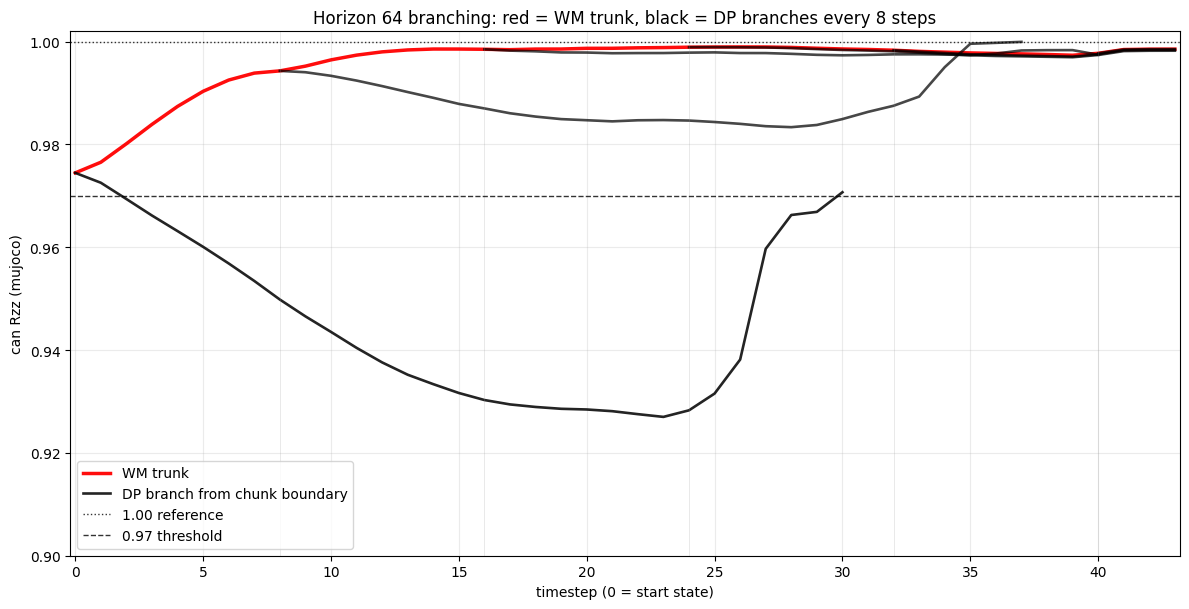

In [13]:
# Plot-only cell: horizon-64 tree view (red WM trunk, black DP branches every 8 steps).
if "h64_branch_results" not in globals() or len(h64_branch_results) == 0:
    raise RuntimeError("Missing horizon64 run data in memory. Run Cell 11 first.")

plt.figure(figsize=(12.0, 6.2))

branch_keys = sorted([int(k) for k in h64_branch_results.keys()])
k_trunk = int(max(branch_keys))
trunk = np.asarray(h64_branch_results[k_trunk], dtype=np.float32)

# Red WM trunk.
plt.plot(np.arange(len(trunk)), trunk, color="red", linewidth=2.5, alpha=0.95, label="WM trunk")

# Black DP branches split from the WM trunk every 8 steps.
for k in branch_keys:
    if k == k_trunk:
        continue
    arr = np.asarray(h64_branch_results[k], dtype=np.float32)
    t0 = min(int(8 * k), len(arr) - 1)
    plt.plot(
        np.arange(t0, len(arr)),
        arr[t0:],
        color="black",
        linewidth=1.9,
        alpha=0.86 if k == 0 else 0.72,
        label="DP branch from chunk boundary" if k == 0 else None,
    )

# Visual split markers every 8 steps up to reached horizon.
max_t = max([len(np.asarray(v)) for v in h64_branch_results.values()]) - 1
for t in range(8, max_t + 1, 8):
    plt.axvline(t, color="#999999", linewidth=0.7, alpha=0.22)

plt.axhline(1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.8, label="1.00 reference")
plt.axhline(0.97, color="black", linestyle="--", linewidth=1.0, alpha=0.8, label="0.97 threshold")

all_vals = np.concatenate([np.asarray(v, dtype=np.float32) for v in h64_branch_results.values()])
plt.ylim(min(float(np.min(all_vals)) - 0.005, 0.90), 1.002)
plt.xlim(-0.2, max_t + 0.2)
plt.xlabel("timestep (0 = start state)")
plt.ylabel("can Rzz (mujoco)")
plt.title("Horizon 64 branching: red = WM trunk, black = DP branches every 8 steps")
plt.grid(alpha=0.25)

# Deduplicate legend labels while preserving order.
handles, labels = plt.gca().get_legend_handles_labels()
dedup = {}
for h, l in zip(handles, labels):
    if l not in dedup:
        dedup[l] = h
plt.legend(list(dedup.values()), list(dedup.keys()), loc="best")

plt.tight_layout()
plt.show()